# Chapter 1 — Exploratory Data Analysis

**Practical Statistics for Data Scientists, 2nd Edition**  
Peter Bruce, Andrew Bruce, Peter Gedeck

## Tujuan Notebook
Notebook ini mereproduksi contoh utama Bab 1 tentang **Exploratory Data Analysis (EDA)** menggunakan Python.

Bagian yang dibahas:
1. Elements of Structured Data
2. Rectangular Data
3. Estimates of Location
4. Estimates of Variability
5. Exploring the Data Distribution
6. Exploring Binary and Categorical Data
7. Correlation
8. Exploring Two or More Variables

**Sumber utama:** *Practical Statistics for Data Scientists*, 2nd Edition, Chapter 1.  
Dataset contoh menggunakan repositori data yang disediakan untuk materi buku.


<a href="https://colab.research.google.com/github/mohamadnurtaufiq/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [ ]:
# Dependensi yang digunakan pada Bab 1
%pip -q install wquantiles

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import wquantiles

pd.set_option("display.precision", 3)

BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

def load_book_data(filename, **kwargs):
    return pd.read_csv(BASE + filename, **kwargs)

state = load_book_data("state.csv")
state.head()


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


## 1. Elements of Structured Data

Data statistik dapat memiliki beberapa tipe. Pada dataset `state`, terdapat data kategorikal dan numerik.

- **Numerik diskrit:** data berbentuk hitungan, seperti `Population`.
- **Numerik kontinu:** data yang dapat memiliki nilai pecahan, seperti `Murder.Rate`.
- **Kategorikal:** label atau kelompok, seperti `State`.
- **Biner:** variabel kategorikal yang hanya mempunyai dua kategori.

Memahami tipe data penting karena jenis variabel menentukan operasi statistik dan visualisasi yang sesuai.


In [ ]:
# Melihat tipe setiap kolom
state.dtypes


,0
State,object
Population,int64
Murder.Rate,float64
Abbreviation,object


In [ ]:
# Mengubah kolom label menjadi categorical data
state = state.copy()
state["State"] = state["State"].astype("category")
state["Abbreviation"] = state["Abbreviation"].astype("category")

state.dtypes


,0
State,category
Population,int64
Murder.Rate,float64
Abbreviation,category


## 2. Rectangular Data

**Rectangular data** adalah data yang tersusun dalam baris dan kolom.

Pada dataset `state`:
- satu baris merepresentasikan satu negara bagian;
- satu kolom merepresentasikan satu variabel;
- setiap kolom memiliki tipe data tertentu;
- index digunakan untuk mengidentifikasi baris.


In [ ]:
print("Ukuran data:", state.shape)
print("\nInformasi struktur:")
state.info()


Ukuran data: (50, 4)

Informasi struktur:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   State         50 non-null     category
 1   Population    50 non-null     int64   
 2   Murder.Rate   50 non-null     float64 
 3   Abbreviation  50 non-null     category
dtypes: category(2), float64(1), int64(1)
memory usage: 5.9 KB


## 3. Estimates of Location

Ukuran lokasi digunakan untuk menggambarkan titik tengah atau lokasi suatu distribusi.

Beberapa ukuran yang digunakan:
- **Mean:** rata-rata aritmetika.
- **Weighted mean:** rata-rata dengan bobot.
- **Median:** nilai tengah setelah data diurutkan.
- **Weighted median:** median yang memperhitungkan bobot.
- **Trimmed mean:** rata-rata setelah sebagian nilai ekstrem pada kedua ujung data dihilangkan.

Mean dapat dipengaruhi nilai ekstrem, sedangkan median dan trimmed mean relatif lebih tahan terhadap nilai ekstrem.


In [ ]:
population = state["Population"]

mean_population = population.mean()
median_population = population.median()
trimmed_population = stats.trim_mean(population, proportiontocut=0.10)

print(f"Mean          : {mean_population:,.0f}")
print(f"Trimmed mean  : {trimmed_population:,.0f}")
print(f"Median        : {median_population:,.0f}")


Mean          : 6,162,876
Trimmed mean  : 4,783,697
Median        : 4,436,370


**Interpretasi:** Pada data populasi negara bagian, mean lebih besar daripada median. Perbedaan ini menunjukkan bahwa beberapa negara bagian dengan populasi besar menarik nilai mean ke arah yang lebih tinggi. Trimmed mean mengurangi pengaruh nilai ekstrem dengan membuang 10% data pada masing-masing ujung distribusi.


In [ ]:
# Weighted mean dan weighted median untuk Murder Rate
weighted_mean = np.average(
    state["Murder.Rate"],
    weights=state["Population"]
)

weighted_median = wquantiles.median(
    state["Murder.Rate"],
    weights=state["Population"]
)

print(f"Weighted mean   : {weighted_mean:.3f}")
print(f"Weighted median : {weighted_median:.3f}")


Weighted mean   : 4.446
Weighted median : 4.400


**Interpretasi:** Weighted mean memberikan kontribusi lebih besar kepada negara bagian dengan populasi lebih besar. Weighted median juga memperhitungkan bobot populasi saat menentukan posisi tengah data.


## 4. Estimates of Variability

Ukuran variabilitas menunjukkan seberapa menyebar data.

Beberapa ukuran yang digunakan:
- **Standard deviation:** mengukur penyebaran data terhadap mean.
- **Variance:** kuadrat dari standard deviation.
- **Range:** selisih nilai maksimum dan minimum.
- **IQR (Interquartile Range):** selisih kuartil ketiga dan kuartil pertama.
- **MAD (Median Absolute Deviation):** ukuran penyebaran yang berbasis median dan lebih tahan terhadap nilai ekstrem.


In [ ]:
# Standard deviation
std_population = state["Population"].std()

# IQR
iqr_population = (
    state["Population"].quantile(0.75)
    - state["Population"].quantile(0.25)
)

# MAD
mad_population = (
    state["Population"] - state["Population"].median()
).abs().median()

print(f"Standard deviation : {std_population:,.0f}")
print(f"IQR                 : {iqr_population:,.0f}")
print(f"MAD                 : {mad_population:,.0f}")


Standard deviation : 6,848,235
IQR                 : 4,847,308
MAD                 : 2,596,702


**Interpretasi:** Standard deviation menggunakan mean sebagai pusat penyebaran, sedangkan IQR hanya menggunakan kuartil tengah 50% data. MAD menggunakan median sehingga lebih tahan terhadap pengaruh nilai ekstrem.


## 5. Exploring the Data Distribution

Distribusi data dapat dilihat menggunakan percentile, boxplot, frequency table, dan histogram. Visualisasi membantu melihat pusat data, penyebaran, bentuk distribusi, serta kemungkinan nilai ekstrem.


In [ ]:
# Percentile Murder Rate
percentages = [0.05, 0.25, 0.5, 0.75, 0.95]
percentile_table = pd.DataFrame(
    state["Murder.Rate"].quantile(percentages)
)
percentile_table.index = [f"{p * 100:.0f}%" for p in percentages]

percentile_table


,Murder.Rate
5%,1.600
25%,2.425
50%,4.000
75%,5.550
95%,6.510


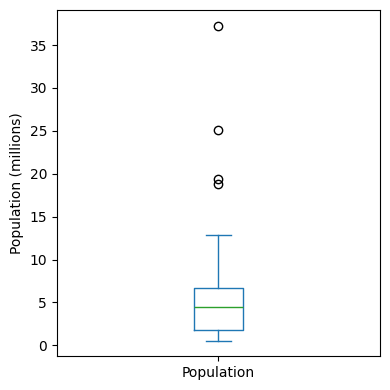

In [ ]:
# Boxplot Population
ax = (state["Population"] / 1_000_000).plot.box(figsize=(4, 4))
ax.set_ylabel("Population (millions)")
plt.tight_layout()
plt.show()


**Interpretasi boxplot:** Boxplot memperlihatkan median, kuartil, rentang data, dan kemungkinan nilai pencilan. Pada data populasi, beberapa negara bagian mempunyai populasi jauh lebih besar daripada sebagian besar negara bagian lainnya.


In [ ]:
# Membagi Population menjadi 10 kelompok interval
binnedPopulation = pd.cut(state["Population"], 10)
print(binnedPopulation.value_counts())


Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64


In [ ]:
# Ringkasan setiap kelompok Population
binnedPopulation.name = "binnedPopulation"
df = pd.concat([state, binnedPopulation], axis=1)
df = df.sort_values(by="Population")

groups = []
for group, subset in df.groupby(by="binnedPopulation", observed=False):
    groups.append({
        "BinRange": group,
        "Count": len(subset),
        "States": ",".join(subset["Abbreviation"].astype(str))
    })

pd.DataFrame(groups)


,BinRange,Count,States
0,"(526935.67, 4232659.0]",24,"WY,VT,ND,AK,SD,DE,MT,RI,NH,ME,HI,ID,NE,WV,NM,N..."
1,"(4232659.0, 7901692.0]",14,"KY,LA,SC,AL,CO,MN,WI,MD,MO,TN,AZ,IN,MA,WA"
2,"(7901692.0, 11570725.0]",6,"VA,NJ,NC,GA,MI,OH"
3,"(11570725.0, 15239758.0]",2,"PA,IL"
4,"(15239758.0, 18908791.0]",1,FL
5,"(18908791.0, 22577824.0]",1,NY
6,"(22577824.0, 26246857.0]",1,TX
7,"(26246857.0, 29915890.0]",0,
8,"(29915890.0, 33584923.0]",0,
9,"(33584923.0, 37253956.0]",1,CA


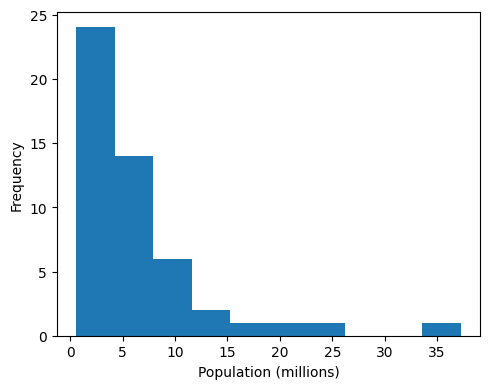

In [ ]:
# Histogram Population
ax = (state["Population"] / 1_000_000).plot.hist(
    figsize=(5, 4),
    bins=10
)
ax.set_xlabel("Population (millions)")
plt.tight_layout()
plt.show()


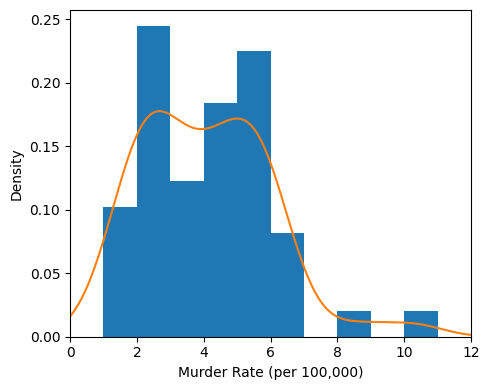

In [ ]:
# Histogram dan density Murder Rate
ax = state["Murder.Rate"].plot.hist(
    density=True,
    xlim=[0, 12],
    bins=range(1, 12),
    figsize=(5, 4)
)
state["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel("Murder Rate (per 100,000)")
plt.tight_layout()
plt.show()


## 6. Exploring Binary and Categorical Data

Data kategorikal dapat diringkas menggunakan frekuensi dan proporsi. Pada bagian ini digunakan dataset keterlambatan penerbangan dan data pinjaman untuk melihat bagaimana kategori dapat dibandingkan.


In [ ]:
# Dataset penyebab keterlambatan penerbangan
dfw = load_book_data("dfw_airline.csv")
dfw


,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


In [ ]:
# Proporsi setiap penyebab keterlambatan
print(100 * dfw / dfw.values.sum())


   Carrier     ATC  Weather  Security  Inbound
0   23.023  30.401    4.025     0.123   42.428


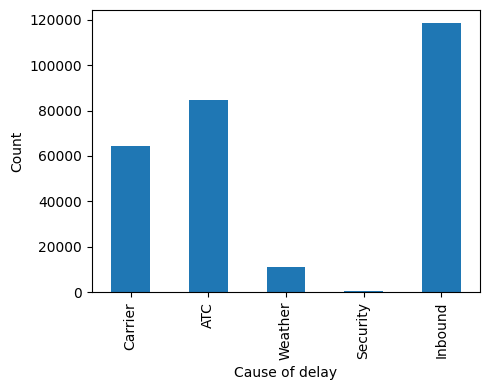

In [ ]:
# Grafik penyebab keterlambatan
ax = dfw.transpose().plot.bar(figsize=(5, 4), legend=False)
ax.set_xlabel("Cause of delay")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 7. Correlation

**Correlation** digunakan untuk melihat hubungan linear antara dua variabel numerik.

Nilai korelasi berada pada rentang -1 sampai 1:
- mendekati **1**: hubungan linear positif kuat;
- mendekati **-1**: hubungan linear negatif kuat;
- mendekati **0**: hubungan linear lemah atau tidak terlihat.

Korelasi tidak otomatis berarti hubungan sebab-akibat.


In [ ]:
# Dataset sektor dan harga saham S&P 500
sp500_sym = load_book_data("sp500_sectors.csv")
sp500_px = load_book_data("sp500_data.csv.gz", index_col=0)

telecomSymbols = sp500_sym[
    sp500_sym["sector"] == "telecommunications_services"
]["symbol"]

telecom = sp500_px.loc[
    sp500_px.index >= "2012-07-01",
    telecomSymbols
]

telecom.corr()


,T,CTL,FTR,VZ,LVLT
T,1.000,0.475,0.328,0.678,0.279
CTL,0.475,1.000,0.420,0.417,0.287
FTR,0.328,0.420,1.000,0.287,0.260
VZ,0.678,0.417,0.287,1.000,0.242
LVLT,0.279,0.287,0.260,0.242,1.000


In [ ]:
# Data ETF untuk melihat korelasi antar-ETF
etfs = sp500_px.loc[
    sp500_px.index > "2012-07-01",
    sp500_sym[sp500_sym["sector"] == "etf"]["symbol"]
]

etfs.head()


,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
2012-07-02,-0.376,0.096,0.028,-0.243,0.42,-10.40,0.00,0.535,0.028,0.096,0.098,-0.094,0.019,-0.010,0.313,0.019,0.076
2012-07-03,0.376,0.482,0.875,0.728,0.49,-3.52,0.25,0.926,0.996,0.000,-0.045,0.337,0.000,0.000,0.129,0.104,0.236
2012-07-05,0.150,0.096,-0.103,0.149,0.24,6.56,-0.07,-0.172,-0.460,0.306,-0.152,0.103,0.019,-0.143,-0.074,-0.142,0.066
2012-07-06,-0.141,-0.491,0.019,-0.205,-0.52,-8.80,-0.18,-0.229,0.207,0.153,0.080,0.019,-0.429,-0.095,0.120,0.066,-0.227
2012-07-09,0.244,-0.048,-0.056,-0.168,0.43,-0.48,0.46,-0.191,-0.235,-0.201,-0.036,-0.169,0.000,0.353,-0.065,0.019,0.009


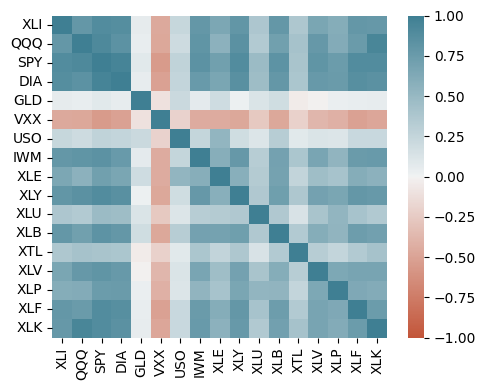

In [ ]:
# Heatmap korelasi ETF
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    etfs.corr(),
    vmin=-1,
    vmax=1,
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    ax=ax
)

plt.tight_layout()
plt.show()


**Interpretasi:** Heatmap membantu melihat pasangan variabel yang memiliki korelasi positif atau negatif. Semakin mendekati 1 atau -1, hubungan linear yang ditunjukkan semakin kuat.


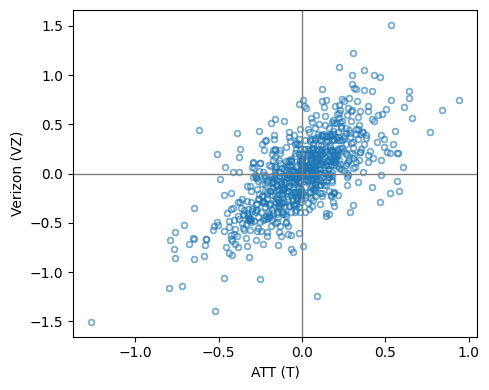

In [ ]:
# Scatter plot saham AT&T dan Verizon
ax = telecom.plot.scatter(
    x="T",
    y="VZ",
    figsize=(5, 4),
    marker="$\u25EF$",
    alpha=0.5
)

ax.set_xlabel("ATT (T)")
ax.set_ylabel("Verizon (VZ)")
ax.axhline(0, color="grey", lw=1)
ax.axvline(0, color="grey", lw=1)

plt.tight_layout()
plt.show()


## 8. Exploring Two or More Variables

Analisis dua variabel dapat digunakan untuk melihat hubungan antara ukuran rumah dan nilai pajak. Untuk data yang sangat banyak, hexbin plot dan density plot dapat membantu melihat konsentrasi observasi.


In [ ]:
# Dataset pajak properti
kc_tax = load_book_data("kc_tax.csv.gz")

kc_tax0 = kc_tax.loc[
    (kc_tax.TaxAssessedValue < 750000) &
    (kc_tax.SqFtTotLiving > 100) &
    (kc_tax.SqFtTotLiving < 3500),
    :
]

print("Ukuran data:", kc_tax0.shape)


Ukuran data: (432693, 3)


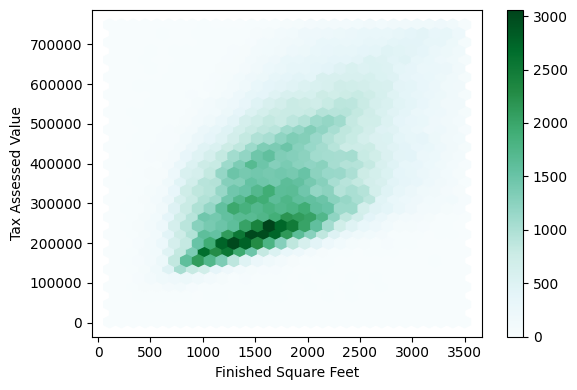

In [ ]:
# Hexbin plot
ax = kc_tax0.plot.hexbin(
    x="SqFtTotLiving",
    y="TaxAssessedValue",
    gridsize=30,
    sharex=False,
    figsize=(6, 4)
)

ax.set_xlabel("Finished Square Feet")
ax.set_ylabel("Tax Assessed Value")

plt.tight_layout()
plt.show()


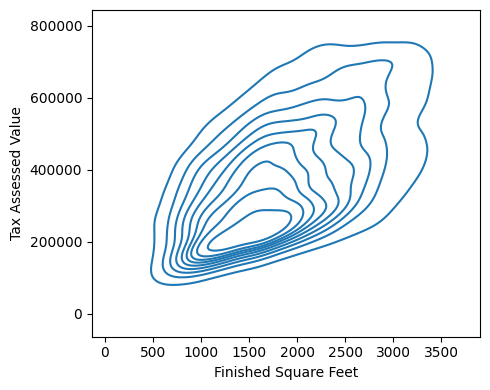

In [ ]:
# KDE plot
fig, ax = plt.subplots(figsize=(5, 4))

sns.kdeplot(
    data=kc_tax0.sample(min(10000, len(kc_tax0)), random_state=42),
    x="SqFtTotLiving",
    y="TaxAssessedValue",
    ax=ax
)

ax.set_xlabel("Finished Square Feet")
ax.set_ylabel("Tax Assessed Value")

plt.tight_layout()
plt.show()


## Categorical Data dan Crosstab

Crosstab digunakan untuk melihat hubungan antara dua variabel kategorikal. Contohnya adalah grade dan status pinjaman.


In [ ]:
# Dataset pinjaman
lc_loans = load_book_data("lc_loans.csv")
lc_loans.head()


,status,grade
0,Fully Paid,B
1,Charged Off,C
2,Fully Paid,C
3,Fully Paid,C
4,Current,B


In [ ]:
# Crosstab grade dan status pinjaman
crosstab = lc_loans.pivot_table(
    index="grade",
    columns="status",
    aggfunc=lambda x: len(x),
    margins=True
)

crosstab


status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


In [ ]:
# Mengubah jumlah menjadi proporsi
df = crosstab.copy().loc["A":"G", :].astype(float)

df.loc[:, "Charged Off":"Late"] = (
    df.loc[:, "Charged Off":"Late"]
    .div(df["All"], axis=0)
)

df["All"] = df["All"] / sum(df["All"])

perc_crosstab = df
perc_crosstab


status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,0.022,0.690,0.282,0.006,0.161
B,0.040,0.709,0.235,0.016,0.294
C,0.050,0.736,0.191,0.023,0.268
D,0.067,0.717,0.184,0.031,0.165
E,0.082,0.708,0.171,0.039,0.077
F,0.118,0.654,0.180,0.047,0.029
G,0.126,0.614,0.198,0.061,0.007


**Interpretasi:** Crosstab memberikan gambaran jumlah observasi pada setiap kombinasi kategori. Ketika diubah menjadi proporsi, perbandingan antar-grade menjadi lebih mudah karena ukuran kelompok dapat dibandingkan dalam skala yang sama.


## Boxplot dan Violin Plot

Boxplot dan violin plot dapat digunakan untuk membandingkan distribusi numerik berdasarkan kategori.


In [ ]:
# Statistik keterlambatan penerbangan
airline_stats = load_book_data("airline_stats.csv")
airline_stats.head()


,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153,1.972,0.762,American
1,5.960,3.706,1.586,American
2,7.157,2.706,2.027,American
3,12.100,11.033,0.000,American
4,7.333,3.366,1.774,American


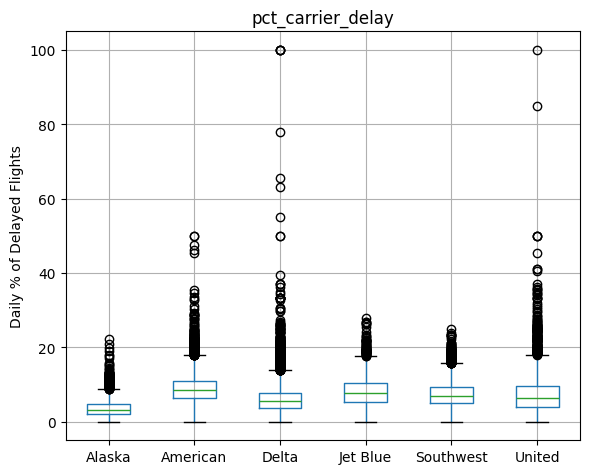

In [ ]:
# Boxplot persentase keterlambatan berdasarkan maskapai
ax = airline_stats.boxplot(
    by="airline",
    column="pct_carrier_delay",
    figsize=(6, 5)
)

ax.set_xlabel("")
ax.set_ylabel("Daily % of Delayed Flights")
plt.suptitle("")
plt.tight_layout()
plt.show()


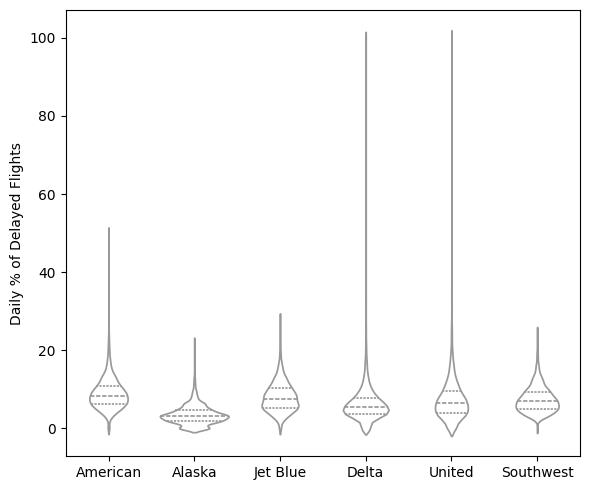

In [ ]:
# Violin plot
fig, ax = plt.subplots(figsize=(6, 5))

sns.violinplot(
    data=airline_stats,
    x="airline",
    y="pct_carrier_delay",
    ax=ax,
    inner="quartile",
    color="white"
)

ax.set_xlabel("")
ax.set_ylabel("Daily % of Delayed Flights")

plt.tight_layout()
plt.show()


## Faceting

Faceting membagi visualisasi berdasarkan kategori sehingga pola antar-kelompok dapat dibandingkan. Contoh berikut membandingkan hubungan luas rumah dan nilai pajak berdasarkan kode pos.


In [ ]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[
    kc_tax0.ZipCode.isin(zip_codes),
    :
]

kc_tax_zip.head()


,TaxAssessedValue,SqFtTotLiving,ZipCode
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0
10,202000.0,830,98108.0
11,210000.0,1130,98108.0
12,193000.0,1560,98108.0


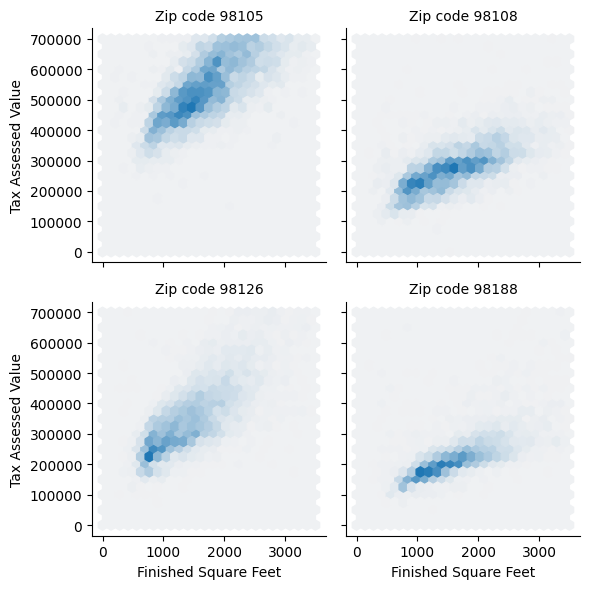

In [ ]:
def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(
    kc_tax_zip,
    col="ZipCode",
    col_wrap=2
)

g.map(
    hexbin,
    "SqFtTotLiving",
    "TaxAssessedValue",
    extent=[0, 3500, 0, 700000]
)

g.set_axis_labels(
    "Finished Square Feet",
    "Tax Assessed Value"
)

g.set_titles("Zip code {col_name:.0f}")

plt.tight_layout()
plt.show()


# Kesimpulan Bab 1

Bab 1 memperkenalkan **Exploratory Data Analysis (EDA)** sebagai langkah awal untuk memahami data.

Hal utama yang dipelajari:
- mengenali tipe dan struktur data;
- menggunakan mean, median, weighted mean, weighted median, dan trimmed mean;
- mengukur penyebaran menggunakan standard deviation, IQR, dan MAD;
- memahami distribusi melalui percentile, histogram, dan boxplot;
- menganalisis data kategorikal dengan frekuensi dan crosstab;
- memahami correlation dan menampilkannya dengan heatmap/scatter plot;
- membandingkan beberapa variabel menggunakan hexbin, KDE, violin plot, dan faceting.

EDA membantu memahami karakteristik data sebelum melakukan analisis statistik atau membangun model machine learning.
